# HW10-11 — Computer Vision in PyTorch (S10–S11)

Часть A (S10): классификация изображений (CIFAR100), 4 эксперимента C1–C4.

Часть B (S11): segmentation track (OxfordIIITPet), 2 режима постобработки V1–V2.

Все артефакты сохраняются в `./artifacts/`.

In [1]:
import os
import sys
import json
import random
import asyncio
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, random_split

import torchvision
import torchvision.transforms as T
from torchvision import datasets
from torchvision.utils import make_grid

import matplotlib.pyplot as plt

if sys.platform == 'win32':
    try:
        asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())
    except Exception:
        pass

print('torch', torch.__version__)
print('torchvision', torchvision.__version__)

cwd = Path.cwd().resolve()
if (cwd / 'homeworks' / 'HW10-11').exists():
    REPO_ROOT = cwd
    HW_DIR = cwd / 'homeworks' / 'HW10-11'
elif cwd.name == 'HW10-11':
    HW_DIR = cwd
    REPO_ROOT = cwd.parents[1]  # .../homeworks/HW10-11 -> repo root
else:
    REPO_ROOT = cwd
    HW_DIR = cwd / 'homeworks' / 'HW10-11' if (cwd / 'homeworks').exists() else cwd

ARTIFACTS_DIR = HW_DIR / 'artifacts'
FIG_DIR = ARTIFACTS_DIR / 'figures'
DATA_DIR = REPO_ROOT / 'data' / 'hw10-11'

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('REPO_ROOT:', REPO_ROOT)
print('HW_DIR:', HW_DIR)
print('DATA_DIR:', DATA_DIR)
print('ARTIFACTS_DIR:', ARTIFACTS_DIR)
print('FIG_DIR:', FIG_DIR)

RUNS_PATH = ARTIFACTS_DIR / 'runs.csv'
RUNS_HEADER = 'experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes\n'
with open(RUNS_PATH, 'w', encoding='utf-8', newline='') as f:
    f.write(RUNS_HEADER)
print('initialized:', RUNS_PATH)


torch 2.10.0+cpu
torchvision 0.25.0+cpu
device: cpu
REPO_ROOT: C:\Users\MI\projects\AI\AI-Engineering
HW_DIR: C:\Users\MI\projects\AI\AI-Engineering\homeworks\HW10-11
DATA_DIR: C:\Users\MI\projects\AI\AI-Engineering\data\hw10-11
ARTIFACTS_DIR: C:\Users\MI\projects\AI\AI-Engineering\homeworks\HW10-11\artifacts
FIG_DIR: C:\Users\MI\projects\AI\AI-Engineering\homeworks\HW10-11\artifacts\figures
initialized: C:\Users\MI\projects\AI\AI-Engineering\homeworks\HW10-11\artifacts\runs.csv


C:\Users\MI\AppData\Local\Temp\ipykernel_22784\383766620.py:24: DeprecationWarning: 'asyncio.WindowsSelectorEventLoopPolicy' is deprecated and slated for removal in Python 3.16
  asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())
C:\Users\MI\AppData\Local\Temp\ipykernel_22784\383766620.py:24: DeprecationWarning: 'asyncio.set_event_loop_policy' is deprecated and slated for removal in Python 3.16
  asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())


## Part A (S10): Image classification — CIFAR100

Требования: `torchvision.datasets.*`, train/val/test, sanity-check, 4 эксперимента C1–C4 (CNN base/aug + ResNet18 head-only/finetune), выбор лучшего по `best_val_accuracy`, тест только один раз.

In [2]:
NUM_WORKERS = 0  # Windows-friendly
BATCH_SIZE = 128

cifar_mean = (0.5071, 0.4867, 0.4408)
cifar_std = (0.2675, 0.2565, 0.2761)

transform_base = T.Compose([
    T.ToTensor(),
    T.Normalize(cifar_mean, cifar_std),
])

transform_aug = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomCrop(32, padding=4, padding_mode='reflect'),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    T.ToTensor(),
    T.Normalize(cifar_mean, cifar_std),
])

resnet_weights = torchvision.models.ResNet18_Weights.DEFAULT
transform_resnet = resnet_weights.transforms()

train_full_base = datasets.CIFAR100(root=DATA_DIR, train=True, download=True, transform=transform_base)
train_full_aug = datasets.CIFAR100(root=DATA_DIR, train=True, download=False, transform=transform_aug)
train_full_resnet = datasets.CIFAR100(root=DATA_DIR, train=True, download=False, transform=transform_resnet)

test_base = datasets.CIFAR100(root=DATA_DIR, train=False, download=False, transform=transform_base)
test_resnet = datasets.CIFAR100(root=DATA_DIR, train=False, download=False, transform=transform_resnet)

num_classes = 100

val_ratio = 0.2
n_total = len(train_full_base)
n_val = int(n_total * val_ratio)
n_train = n_total - n_val

split_gen = torch.Generator().manual_seed(SEED)
train_idx_subset, val_idx_subset = random_split(range(n_total), [n_train, n_val], generator=split_gen)
train_indices = list(train_idx_subset)
val_indices = list(val_idx_subset)

TRAIN_N = 3000
VAL_N = 1000
if len(train_indices) > TRAIN_N:
    train_indices = train_indices[:TRAIN_N]
if len(val_indices) > VAL_N:
    val_indices = val_indices[:VAL_N]

train_base = Subset(train_full_base, train_indices)
val_base = Subset(train_full_base, val_indices)

train_aug = Subset(train_full_aug, train_indices)
val_aug = Subset(train_full_aug, val_indices)

train_resnet = Subset(train_full_resnet, train_indices)
val_resnet = Subset(train_full_resnet, val_indices)

train_loader_base = DataLoader(train_base, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=False)
val_loader_base = DataLoader(val_base, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=False)

train_loader_aug = DataLoader(train_aug, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=False)
val_loader_aug = DataLoader(val_aug, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=False)

test_loader_base = DataLoader(test_base, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=False)
test_loader_resnet = DataLoader(test_resnet, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=False)

train_loader_resnet = DataLoader(train_resnet, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=False)
val_loader_resnet = DataLoader(val_resnet, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=False)

xb, yb = next(iter(train_loader_base))
print('batch x:', xb.shape, xb.dtype)
print('batch y:', yb.shape, yb.dtype)
print('num_classes:', num_classes)
print('train size:', len(train_indices), 'val size:', len(val_indices), 'test size:', len(test_base))


C:\Users\MI\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


batch x: torch.Size([128, 3, 32, 32]) torch.float32
batch y: torch.Size([128]) torch.int64
num_classes: 100
train size: 3000 val size: 1000 test size: 10000


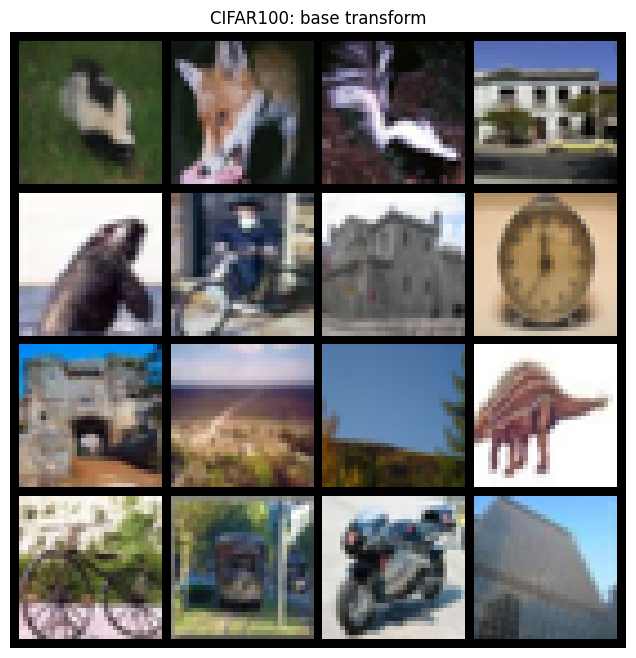

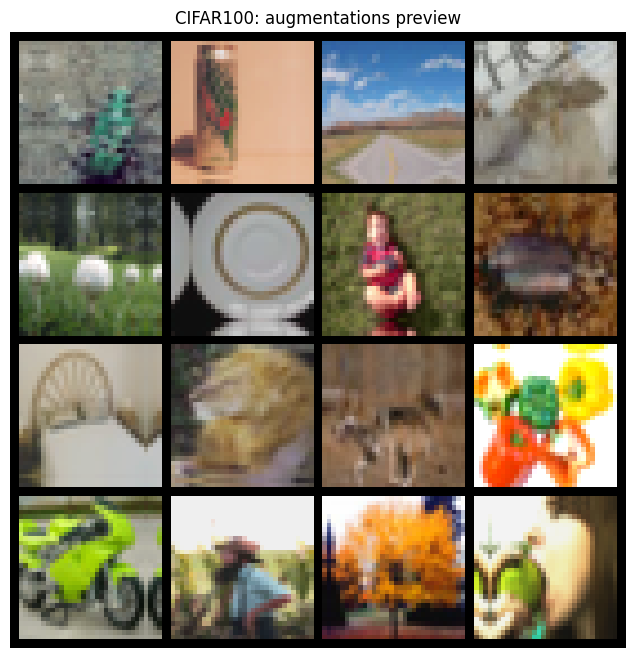

saved: C:\Users\MI\projects\AI\AI-Engineering\homeworks\HW10-11\artifacts\figures\augmentations_preview.png


In [3]:
def show_batch(dl, title: str, n: int = 16):
    x, y = next(iter(dl))
    x = x[:n]

    mean = torch.tensor(cifar_mean).view(1, 3, 1, 1)
    std = torch.tensor(cifar_std).view(1, 3, 1, 1)
    x_vis = (x * std + mean).clamp(0, 1)

    grid = make_grid(x_vis, nrow=4)
    plt.figure(figsize=(8, 8))
    plt.title(title)
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis('off')
    plt.show()

show_batch(train_loader_base, 'CIFAR100: base transform')
show_batch(train_loader_aug, 'CIFAR100: augmentations preview')

x, _ = next(iter(train_loader_aug))
mean = torch.tensor(cifar_mean).view(1, 3, 1, 1)
std = torch.tensor(cifar_std).view(1, 3, 1, 1)
x_vis = (x[:16] * std + mean).clamp(0, 1)
plt.figure(figsize=(8, 8))
plt.imshow(make_grid(x_vis, nrow=4).permute(1, 2, 0))
plt.axis('off')
plt.tight_layout()
plt.savefig(FIG_DIR / 'augmentations_preview.png', dpi=160)
plt.close()
print('saved:', FIG_DIR / 'augmentations_preview.png')


In [4]:
@torch.no_grad()
def accuracy_from_logits(logits: torch.Tensor, y: torch.Tensor) -> float:
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    n = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        bs = x.size(0)
        total_loss += loss.item() * bs
        total_acc += accuracy_from_logits(logits.detach(), y) * bs
        n += bs

    return total_loss / n, total_acc / n


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = criterion(logits, y)

        bs = x.size(0)
        total_loss += loss.item() * bs
        total_acc += accuracy_from_logits(logits, y) * bs
        n += bs

    return total_loss / n, total_acc / n


def plot_curves(history: dict, title: str, out_path: Path):
    epochs = np.arange(1, len(history['train_loss']) + 1)

    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].plot(epochs, history['train_loss'], label='обучение')
    ax[0].plot(epochs, history['val_loss'], label='валидация')
    ax[0].set_title('Функция потерь')
    ax[0].set_xlabel('epoch')
    ax[0].grid(True)
    ax[0].legend()

    ax[1].plot(epochs, history['train_acc'], label='обучение')
    ax[1].plot(epochs, history['val_acc'], label='валидация')
    ax[1].set_title('Точность')
    ax[1].set_xlabel('epoch')
    ax[1].grid(True)
    ax[1].legend()

    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(out_path, dpi=160)
    plt.close(fig)


def append_run(row: dict, runs_path: Path = ARTIFACTS_DIR / 'runs.csv'):
    import csv

    runs_path.parent.mkdir(parents=True, exist_ok=True)
    exists = runs_path.exists()

    with open(runs_path, 'a', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=[
            'experiment_id','task','dataset','seed','model_summary','optimizer','lr','epochs_trained',
            'best_val_accuracy','test_accuracy','precision','recall','mean_iou','notes'
        ])
        if not exists or runs_path.stat().st_size == 0:
            writer.writeheader()
        writer.writerow(row)


In [5]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 48

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 24

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 12

            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.classifier(x)


def build_resnet18(num_classes: int = 10, head_only: bool = True, finetune_layer4: bool = False):
    model = torchvision.models.resnet18(weights=resnet_weights)
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    for p in model.parameters():
        p.requires_grad = False

    for p in model.fc.parameters():
        p.requires_grad = True

    if finetune_layer4:
        for p in model.layer4.parameters():
            p.requires_grad = True

    return model


def count_trainable_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


In [6]:
EPOCHS = 2
LR_CNN = 1e-3
LR_RESNET_HEAD = 1e-3
LR_RESNET_FT = 1e-4

criterion = nn.CrossEntropyLoss()
results_A = {}


def run_classification_experiment(experiment_id: str, model: nn.Module, train_loader, val_loader, optimizer, epochs: int):
    model = model.to(device)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = -1.0
    best_state = None

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(
            f"{experiment_id} | epoch {epoch:02d}/{epochs} | "
            f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
            f"val loss {va_loss:.4f} acc {va_acc:.4f}"
        )

    return history, best_val_acc, best_state


### C1 — simple-cnn-base (без аугментаций)

In [7]:
set_seed(SEED)
model_c1 = SimpleCNN(num_classes=num_classes)
opt_c1 = torch.optim.Adam(model_c1.parameters(), lr=LR_CNN)
hist_c1, best_c1, state_c1 = run_classification_experiment('C1', model_c1, train_loader_base, val_loader_base, opt_c1, EPOCHS)
results_A['C1'] = {'best_val_acc': best_c1, 'history': hist_c1, 'state': state_c1, 'model_summary': 'SimpleCNN'}
append_run({
    'experiment_id': 'C1', 'task': 'classification', 'dataset': 'CIFAR100', 'seed': SEED,
    'model_summary': 'SimpleCNN(base)', 'optimizer': 'Adam', 'lr': LR_CNN, 'epochs_trained': EPOCHS,
    'best_val_accuracy': best_c1, 'test_accuracy': '', 'precision': '', 'recall': '', 'mean_iou': '',
    'notes': 'no augmentation'
})


C1 | epoch 01/2 | train loss 4.5914 acc 0.0123 | val loss 4.5301 acc 0.0220


C1 | epoch 02/2 | train loss 4.4242 acc 0.0313 | val loss 4.3887 acc 0.0380


### C2 — simple-cnn-aug (та же CNN, но с аугментациями)

In [8]:
set_seed(SEED)
model_c2 = SimpleCNN(num_classes=num_classes)
opt_c2 = torch.optim.Adam(model_c2.parameters(), lr=LR_CNN)
hist_c2, best_c2, state_c2 = run_classification_experiment('C2', model_c2, train_loader_aug, val_loader_aug, opt_c2, EPOCHS)
results_A['C2'] = {'best_val_acc': best_c2, 'history': hist_c2, 'state': state_c2, 'model_summary': 'SimpleCNN'}
append_run({
    'experiment_id': 'C2', 'task': 'classification', 'dataset': 'CIFAR100', 'seed': SEED,
    'model_summary': 'SimpleCNN(aug)', 'optimizer': 'Adam', 'lr': LR_CNN, 'epochs_trained': EPOCHS,
    'best_val_accuracy': best_c2, 'test_accuracy': '', 'precision': '', 'recall': '', 'mean_iou': '',
    'notes': 'with augmentation'
})


C2 | epoch 01/2 | train loss 4.5953 acc 0.0127 | val loss 4.5450 acc 0.0270


C2 | epoch 02/2 | train loss 4.4648 acc 0.0270 | val loss 4.4404 acc 0.0270


### C3 — resnet18-head-only (pretrained, backbone frozen)

In [9]:
set_seed(SEED)
model_c3 = build_resnet18(num_classes=num_classes, head_only=True, finetune_layer4=False)
print('C3 trainable params:', count_trainable_params(model_c3))
opt_c3 = torch.optim.Adam(filter(lambda p: p.requires_grad, model_c3.parameters()), lr=LR_RESNET_HEAD)
hist_c3, best_c3, state_c3 = run_classification_experiment('C3', model_c3, train_loader_resnet, val_loader_resnet, opt_c3, EPOCHS)
results_A['C3'] = {'best_val_acc': best_c3, 'history': hist_c3, 'state': state_c3, 'model_summary': 'ResNet18(head-only)'}
append_run({
    'experiment_id': 'C3', 'task': 'classification', 'dataset': 'CIFAR100', 'seed': SEED,
    'model_summary': 'ResNet18(pretrained, head-only)', 'optimizer': 'Adam', 'lr': LR_RESNET_HEAD, 'epochs_trained': EPOCHS,
    'best_val_accuracy': best_c3, 'test_accuracy': '', 'precision': '', 'recall': '', 'mean_iou': '',
    'notes': 'frozen backbone, train fc'
})


C3 trainable params: 51300


C3 | epoch 01/2 | train loss 4.5224 acc 0.0433 | val loss 4.1920 acc 0.0880


C3 | epoch 02/2 | train loss 3.7684 acc 0.2030 | val loss 3.6818 acc 0.2080


### C4 — resnet18-finetune (partial fine-tune: layer4 + fc)

In [10]:
set_seed(SEED)
model_c4 = build_resnet18(num_classes=num_classes, head_only=False, finetune_layer4=True)
print('C4 trainable params:', count_trainable_params(model_c4))
opt_c4 = torch.optim.Adam(filter(lambda p: p.requires_grad, model_c4.parameters()), lr=LR_RESNET_FT)
hist_c4, best_c4, state_c4 = run_classification_experiment('C4', model_c4, train_loader_resnet, val_loader_resnet, opt_c4, EPOCHS)
results_A['C4'] = {'best_val_acc': best_c4, 'history': hist_c4, 'state': state_c4, 'model_summary': 'ResNet18(finetune layer4+fc)'}
append_run({
    'experiment_id': 'C4', 'task': 'classification', 'dataset': 'CIFAR100', 'seed': SEED,
    'model_summary': 'ResNet18(pretrained, finetune layer4+fc)', 'optimizer': 'Adam', 'lr': LR_RESNET_FT, 'epochs_trained': EPOCHS,
    'best_val_accuracy': best_c4, 'test_accuracy': '', 'precision': '', 'recall': '', 'mean_iou': '',
    'notes': 'unfrozen layer4 + fc'
})


C4 trainable params: 8445028


C4 | epoch 01/2 | train loss 4.4310 acc 0.0667 | val loss 4.0745 acc 0.1360


C4 | epoch 02/2 | train loss 3.2619 acc 0.4230 | val loss 3.4818 acc 0.2390


### Сравнение C1–C4, выбор лучшего по val_accuracy, сохранение графиков

In [11]:
best_vals = {k: v['best_val_acc'] for k, v in results_A.items()}
print('best val acc:', best_vals)

plt.figure(figsize=(6, 4))
plt.bar(best_vals.keys(), best_vals.values())
plt.ylim(0, 1)
plt.grid(True, axis='y')
plt.title('CIFAR100: лучшая точность на валидации (C1-C4)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'classification_compare.png', dpi=160)
plt.close()
print('saved:', FIG_DIR / 'classification_compare.png')

best_exp = max(best_vals, key=best_vals.get)
print('best experiment:', best_exp, 'val_acc:', best_vals[best_exp])

plot_curves(results_A[best_exp]['history'], f"Best classification run: {best_exp}", FIG_DIR / 'classification_curves_best.png')
print('saved:', FIG_DIR / 'classification_curves_best.png')


best val acc: {'C1': 0.03800000008940697, 'C2': 0.027000000089406968, 'C3': 0.20799999976158143, 'C4': 0.23899999928474427}
saved: C:\Users\MI\projects\AI\AI-Engineering\homeworks\HW10-11\artifacts\figures\classification_compare.png
best experiment: C4 val_acc: 0.23899999928474427


saved: C:\Users\MI\projects\AI\AI-Engineering\homeworks\HW10-11\artifacts\figures\classification_curves_best.png


In [12]:
best_state = results_A[best_exp]['state']

if best_exp in ['C1', 'C2']:
    best_model = SimpleCNN(num_classes=num_classes)
    best_model.load_state_dict(best_state)
    best_model = best_model.to(device)
    test_loader = test_loader_base
    model_summary = results_A[best_exp]['model_summary']
elif best_exp in ['C3', 'C4']:
    finetune = (best_exp == 'C4')
    best_model = build_resnet18(num_classes=num_classes, finetune_layer4=finetune)
    best_model.load_state_dict(best_state)
    best_model = best_model.to(device)
    test_loader = test_loader_resnet
    model_summary = results_A[best_exp]['model_summary']
else:
    raise ValueError(best_exp)

set_seed(SEED)
test_loss, test_acc = evaluate(best_model, test_loader, criterion)
print('TEST |', best_exp, '| loss', test_loss, '| acc', test_acc)

best_pt = ARTIFACTS_DIR / 'best_classifier.pt'
torch.save(best_state, best_pt)
print('saved:', best_pt)

best_cfg = {
    'seed': SEED,
    'dataset': 'CIFAR100',
    'split': {'train': len(train_indices), 'val': len(val_indices), 'test': len(test_loader.dataset)},
    'best_experiment_id': best_exp,
    'model_summary': model_summary,
    'epochs': EPOCHS,
    'batch_size': BATCH_SIZE,
    'loss': 'CrossEntropyLoss',
    'optimizers': {
        'C1': {'name': 'Adam', 'lr': LR_CNN},
        'C2': {'name': 'Adam', 'lr': LR_CNN},
        'C3': {'name': 'Adam', 'lr': LR_RESNET_HEAD},
        'C4': {'name': 'Adam', 'lr': LR_RESNET_FT},
    },
    'transforms': {
        'base': 'ToTensor + Normalize(CIFAR100 mean/std)',
        'aug': 'RandomHorizontalFlip + RandomCrop(32,padding=4) + ColorJitter + ToTensor + Normalize',
        'resnet': 'ResNet18_Weights.DEFAULT.transforms()',
    },
    'test_result': {'loss': float(test_loss), 'accuracy': float(test_acc)},
}

best_cfg_path = ARTIFACTS_DIR / 'best_classifier_config.json'
with open(best_cfg_path, 'w', encoding='utf-8') as f:
    json.dump(best_cfg, f, ensure_ascii=False, indent=2)
print('saved:', best_cfg_path)

append_run({
    'experiment_id': f'{best_exp}_TEST', 'task': 'classification', 'dataset': 'CIFAR100', 'seed': SEED,
    'model_summary': model_summary, 'optimizer': '', 'lr': '', 'epochs_trained': EPOCHS,
    'best_val_accuracy': best_vals[best_exp], 'test_accuracy': test_acc,
    'precision': '', 'recall': '', 'mean_iou': '',
    'notes': 'final test evaluation (done once)'
})


TEST | C4 | loss 3.4617386978149414 | acc 0.2583
saved: C:\Users\MI\projects\AI\AI-Engineering\homeworks\HW10-11\artifacts\best_classifier.pt
saved: C:\Users\MI\projects\AI\AI-Engineering\homeworks\HW10-11\artifacts\best_classifier_config.json


## Part B (S11): Structured vision — Segmentation (OxfordIIITPet)

Цель: запустить готовый pretrained пайплайн сегментации, корректно визуализировать маски, посчитать базовые метрики (mean IoU + pixel precision/recall) в двух режимах постобработки V1–V2 и зафиксировать результаты в `artifacts/runs.csv`.

In [13]:
from torchvision.models.segmentation import DeepLabV3_ResNet50_Weights

pet_weights = DeepLabV3_ResNet50_Weights.DEFAULT
pet_preprocess = pet_weights.transforms()


def pet_target_to_tensor(mask_pil):
    t = T.PILToTensor()(mask_pil).squeeze(0).long()  # (H,W)
    return t

pet_train = datasets.OxfordIIITPet(root=DATA_DIR, split='trainval', target_types='segmentation', download=True,
                                  transform=pet_preprocess, target_transform=pet_target_to_tensor)
pet_test = datasets.OxfordIIITPet(root=DATA_DIR, split='test', target_types='segmentation', download=True,
                                 transform=pet_preprocess, target_transform=pet_target_to_tensor)

PET_EVAL_N = min(200, len(pet_test))
g = torch.Generator().manual_seed(SEED)
pet_indices = torch.randperm(len(pet_test), generator=g)[:PET_EVAL_N].tolist()
pet_eval = Subset(pet_test, pet_indices)

pet_loader = DataLoader(pet_eval, batch_size=1, shuffle=False, num_workers=NUM_WORKERS)

x_seg, y_seg = next(iter(pet_loader))
print('seg batch x:', x_seg.shape, x_seg.dtype)
print('seg batch y:', y_seg.shape, y_seg.dtype, 'unique labels:', torch.unique(y_seg)[:10])


seg batch x: torch.Size([1, 3, 520, 693]) torch.float32
seg batch y: torch.Size([1, 375, 500]) torch.int64 unique labels: tensor([1, 2, 3])


In [14]:
seg_model = torchvision.models.segmentation.deeplabv3_resnet50(weights=pet_weights)
seg_model = seg_model.to(device)
seg_model.eval()

VOC_CAT = 8
VOC_DOG = 12


def gt_foreground(mask: torch.Tensor) -> torch.Tensor:
    return (mask == 1) | (mask == 2)


def pred_foreground_from_logits(logits: torch.Tensor, score_threshold: float) -> torch.Tensor:
    probs = logits.softmax(dim=1)
    pet_prob = torch.maximum(probs[:, VOC_CAT], probs[:, VOC_DOG])  # (B,H,W)
    return pet_prob >= score_threshold


def morph_open_close(mask: torch.Tensor, k: int = 5) -> torch.Tensor:
    x = mask.float().unsqueeze(1)  # (B,1,H,W)
    pad = k // 2

    er = 1.0 - F.max_pool2d(1.0 - x, kernel_size=k, stride=1, padding=pad)
    dil = F.max_pool2d(er, kernel_size=k, stride=1, padding=pad)

    dil2 = F.max_pool2d(dil, kernel_size=k, stride=1, padding=pad)
    cl = 1.0 - F.max_pool2d(1.0 - dil2, kernel_size=k, stride=1, padding=pad)

    return (cl.squeeze(1) > 0.5)


@torch.no_grad()
def segmentation_metrics(score_threshold: float, use_morph: bool):
    tp = 0
    fp = 0
    fn = 0
    ious = []

    for x, y in pet_loader:
        x = x.to(device)
        y = y.to(device)

        out = seg_model(x)['out']  # (B,21,H,W)
        out = F.interpolate(out, size=y.shape[-2:], mode='bilinear', align_corners=False)
        pred_fg = pred_foreground_from_logits(out, score_threshold)
        if use_morph:
            pred_fg = morph_open_close(pred_fg, k=5)

        gt_fg = gt_foreground(y)

        tp_b = (pred_fg & gt_fg).sum().item()
        fp_b = (pred_fg & ~gt_fg).sum().item()
        fn_b = ((~pred_fg) & gt_fg).sum().item()

        tp += tp_b
        fp += fp_b
        fn += fn_b

        for i in range(pred_fg.size(0)):
            inter = (pred_fg[i] & gt_fg[i]).sum().item()
            union = (pred_fg[i] | gt_fg[i]).sum().item()
            iou = inter / union if union > 0 else 1.0
            ious.append(iou)

    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    mean_iou = float(np.mean(ious))
    return float(precision), float(recall), mean_iou


def visualize_seg_examples(score_threshold: float, use_morph: bool, n: int = 6):
    n = min(n, len(pet_eval))

    fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(n):
        x, y = pet_eval[i]
        x = x.unsqueeze(0).to(device)  # (1,3,H,W)
        y = y.unsqueeze(0).to(device)  # (1,H,W)

        out = seg_model(x)['out']
        out = F.interpolate(out, size=y.shape[-2:], mode='bilinear', align_corners=False)
        pred_fg = pred_foreground_from_logits(out, score_threshold)
        if use_morph:
            pred_fg = morph_open_close(pred_fg, k=5)

        gt_fg = gt_foreground(y)

        img = x[0].detach().cpu().permute(1, 2, 0)
        img = (img - img.min()) / (img.max() - img.min() + 1e-9)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title('image')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(gt_fg[0].detach().cpu().float(), cmap='gray')
        axes[i, 1].set_title('gt foreground')
        axes[i, 1].axis('off')

        axes[i, 2].imshow(pred_fg[0].detach().cpu().float(), cmap='gray')
        axes[i, 2].set_title('pred foreground')
        axes[i, 2].axis('off')

    fig.tight_layout()
    return fig


In [15]:
prec_v1, rec_v1, miou_v1 = segmentation_metrics(score_threshold=0.3, use_morph=False)
print('V1 | precision', prec_v1, '| recall', rec_v1, '| mean_iou', miou_v1)

prec_v2, rec_v2, miou_v2 = segmentation_metrics(score_threshold=0.7, use_morph=True)
print('V2 | precision', prec_v2, '| recall', rec_v2, '| mean_iou', miou_v2)

append_run({
    'experiment_id': 'V1', 'task': 'segmentation', 'dataset': 'OxfordIIITPet(test subset)', 'seed': SEED,
    'model_summary': 'DeepLabV3_ResNet50(pretrained VOC) | fg=cat/dog prob>=0.3',
    'optimizer': '', 'lr': '', 'epochs_trained': '',
    'best_val_accuracy': '', 'test_accuracy': '',
    'precision': prec_v1, 'recall': rec_v1, 'mean_iou': miou_v1,
    'notes': f'PET_EVAL_N={PET_EVAL_N}; V1 threshold=0.3'
})
append_run({
    'experiment_id': 'V2', 'task': 'segmentation', 'dataset': 'OxfordIIITPet(test subset)', 'seed': SEED,
    'model_summary': 'DeepLabV3_ResNet50(pretrained VOC) | fg=cat/dog prob>=0.7 + morph',
    'optimizer': '', 'lr': '', 'epochs_trained': '',
    'best_val_accuracy': '', 'test_accuracy': '',
    'precision': prec_v2, 'recall': rec_v2, 'mean_iou': miou_v2,
    'notes': f'PET_EVAL_N={PET_EVAL_N}; V2 threshold=0.7 + open/close(k=5)'
})

fig1 = visualize_seg_examples(score_threshold=0.3, use_morph=False, n=6)
fig1.savefig(FIG_DIR / 'segmentation_examples.png', dpi=160)
plt.close(fig1)
print('saved:', FIG_DIR / 'segmentation_examples.png')

plt.figure(figsize=(6, 4))
labels = ['precision', 'recall', 'mean_iou']
v1 = [prec_v1, rec_v1, miou_v1]
v2 = [prec_v2, rec_v2, miou_v2]
x = np.arange(len(labels))
width = 0.35
plt.bar(x - width/2, v1, width, label='V1')
plt.bar(x + width/2, v2, width, label='V2')
plt.xticks(x, labels)
plt.ylim(0, 1)
plt.grid(True, axis='y')
plt.title('Метрики сегментации (бинарный передний план)')
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'segmentation_metrics.png', dpi=160)
plt.close()
print('saved:', FIG_DIR / 'segmentation_metrics.png')


V1 | precision 0.7964582026907541 | recall 0.34408924151477566 | mean_iou 0.320075055727027


V2 | precision 0.8395153239997667 | recall 0.32874924098114455 | mean_iou 0.3167792914487899


saved: C:\Users\MI\projects\AI\AI-Engineering\homeworks\HW10-11\artifacts\figures\segmentation_examples.png


saved: C:\Users\MI\projects\AI\AI-Engineering\homeworks\HW10-11\artifacts\figures\segmentation_metrics.png


## Done

Проверьте, что после выполнения ноутбука в `./artifacts/` появились:

- `runs.csv`
- `best_classifier.pt`
- `best_classifier_config.json`
- `figures/augmentations_preview.png`
- `figures/classification_compare.png`
- `figures/classification_curves_best.png`
- `figures/segmentation_examples.png`
- `figures/segmentation_metrics.png`